## Bath_dMFA_2026 Software 2 - Sample solution

## Passenger vehicles in the EUR20 countries - From inflow to stock

**This software exercise covers calculations of the stock of vehicles in the use phase (accumulation of inflow) and the outflow of end-of-life vehicles from the stock.** It applies the inflow-driven dynamic stock model and serves as preparation of the stock-driven model in the subsequent workbooks.

The data workbook *Bath_dMFA_2026_Software_Data.xlsx* contains a number of parameters for the calculation: Historic inflow of new registration of passenger vehicles in the EUR20 countries from 1990 to 2024, the split of total new registration into gasoline and electric vehicles, and the average lifetime of vehicles in the use phase.

**Using the material from the previous software workbook (data and code), work on completing the following tasks to calculate and interpret the following indicators/quantities**

### Task 1: For the historic data, what are the time series for the inflow of new vehicles into the stock, broken down by drive technology?
Calculate the relevant flows using the Python code below.
Split the inflow into electric and gasoline vehicles as before.

In [1]:
# First, import required libraries:
import pandas as pd   # dataframe library, used for fast import/export from/to excel and for organizing the data.
import numpy as np    # math library
import matplotlib.pyplot as plt  # plotting library
import scipy # library with statistical functions

Read input data from excel into dataframe and convert to numpy array.
Determine and print the shape of the different arrays (_.shape_ function).

In [2]:
# First, the historic inflow:
I_c = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='New registration', index_col=0).values[:,0]
print(I_c.shape) # rows: 35 years 1990-2024

(35,)


In [3]:
# Second, the historic split of the inflow into different drive technologies:
BEVshare_cT = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='BEV_share', index_col=0).values
print(BEVshare_cT.shape) # rows: 71 years 1990-2060, columns: 2 drive technologies

(71, 2)


In [4]:
# Third, the lifetime:
Lifetime_T = pd.read_excel('Bath_dMFA_2026_Software_Data.xlsx', sheet_name='Lifetime', index_col=0).values.transpose()
# For the subsequent calculation of the probability density function, the lifetime list must be a row vector, that's why the .transpose() command.
print(Lifetime_T.shape) # rows: aggregate for all age-cohorts, columns: 2 drive technologies

(2, 1)


We first split the inflow into the two drive technologies as before (copy from the previous workbook):

In [5]:
I_cT = np.einsum('c,cT->cT',I_c,BEVshare_cT[0:35,:]) / 100 

With this preparation, we are ready to tackle the core tasts of this workbook:

### Task 2: Build and analyse the probability density functions (pdf) of discarding the vehicles after use, for each drive technology 

The following equation shows the normally distributed probability of discard "normally distributed lifetime), with mean lifetime $\tau$ and with a standard deviation $\sigma$, a commonly used lifetime model.

$$ pdf(age) = \frac{1}{\sigma \sqrt{2\pi} } e^{-\frac{1}{2}\left(\frac{age-\tau}{\sigma}\right)^2} $$

In the code below, we first generate the pdf function from the lifetime parameter, assuming a normally distributed lifetime with a standard deviation of 30% of the mean, a commonly used assumption.

[[16]
 [13]]
(2, 35)
[[3.21308124e-04 6.29637091e-04 1.18143359e-03 2.12265169e-03
  3.65172927e-03 6.01545970e-03 9.48832352e-03 1.43304741e-02
  2.07244039e-02 2.86981532e-02 3.80518928e-02 4.83113299e-02
  5.87316407e-02 6.83668684e-02 7.62025763e-02 8.13287383e-02
  8.31129751e-02 8.13287383e-02 7.62025763e-02 6.83668684e-02
  5.87316407e-02 4.83113299e-02 3.80518928e-02 2.86981532e-02
  2.07244039e-02 1.43304741e-02 9.48832352e-03 6.01545970e-03
  3.65172927e-03 2.12265169e-03 1.18143359e-03 6.29637091e-04
  3.21308124e-04 1.57001399e-04 7.34574338e-05]
 [3.95456153e-04 8.99525733e-04 1.91591230e-03 3.82106513e-03
  7.13575669e-03 1.24779260e-02 2.04310911e-02 3.13247412e-02
  4.49707576e-02 6.04532559e-02 7.60949730e-02 8.96889662e-02
  9.89848772e-02 1.02292892e-01 9.89848772e-02 8.96889662e-02
  7.60949730e-02 6.04532559e-02 4.49707576e-02 3.13247412e-02
  2.04310911e-02 1.24779260e-02 7.13575669e-03 3.82106513e-03
  1.91591230e-03 8.99525733e-04 3.95456153e-04 1.62790802e-04
 

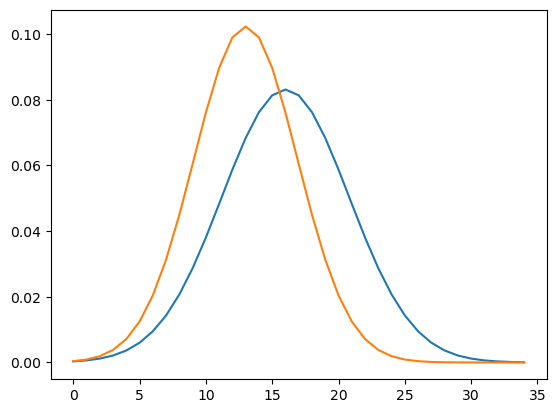

In [6]:
print(Lifetime_T)

pdf = scipy.stats.norm.pdf(np.arange(0,35,1),Lifetime_T,0.3*Lifetime_T) # pdf of the normal distribution with mean lifetime and standard deviation 0.3*lifetime

print(pdf.shape)
print(pdf)

plt.plot(pdf.transpose()) # transpose to have time dimension on x axis, no fan.cy labels and legend here, just a quick look

The curve for gasoline vehicles (blue) is further to the right (indicating a longer lifetime on average) and a slightly wider spread. The curve for BEVs is a bit more narrow and further to the left, indicating a shorter average lifetime.
The area under each curve is 1, indicating that the total propability of the inflow leaving the stock eventually is 100%.

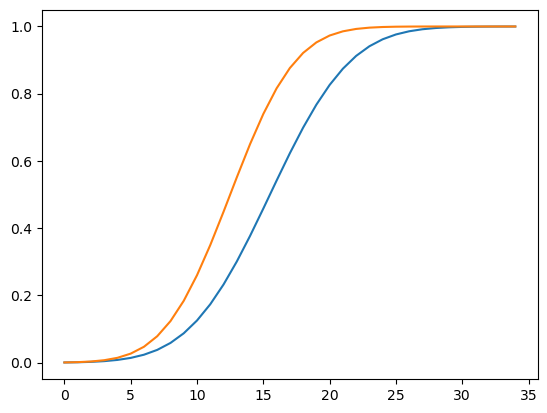

In [7]:
# Check that the pdf sum up to 1 by using the np.cumsum function:
plt.plot(np.cumsum(pdf.transpose(),axis=0)) 
# transpose to have the years on the x axis, then determine the cumulative sum alon this axis.

#### Task 2.1: Repeat the calculation of the lifetime for a wider distribution, e.g., standard deviation = 0.7 * average lifetime!

(2, 35)
[[0.01283909 0.01452774 0.01630795 0.01816096 0.02006392 0.02199028
  0.02391022 0.02579136 0.02759959 0.02930009 0.03085837 0.03224148
  0.0334191  0.03436468 0.03505643 0.03547815 0.03561985 0.03547815
  0.03505643 0.03436468 0.0334191  0.03224148 0.03085837 0.02930009
  0.02759959 0.02579136 0.02391022 0.02199028 0.02006392 0.01816096
  0.01630795 0.01452774 0.01283909 0.01125664 0.00979086]
 [0.01580196 0.01837667 0.02111438 0.02396874 0.02688238 0.0297883
  0.03261213 0.0352751  0.03769752 0.03980274 0.04152107 0.04279369
  0.04357591 0.04383981 0.04357591 0.04279369 0.04152107 0.03980274
  0.03769752 0.0352751  0.03261213 0.0297883  0.02688238 0.02396874
  0.02111438 0.01837667 0.01580196 0.01342489 0.01126849 0.00934494
  0.00765672 0.00619819 0.00495726 0.00391719 0.00305818]]


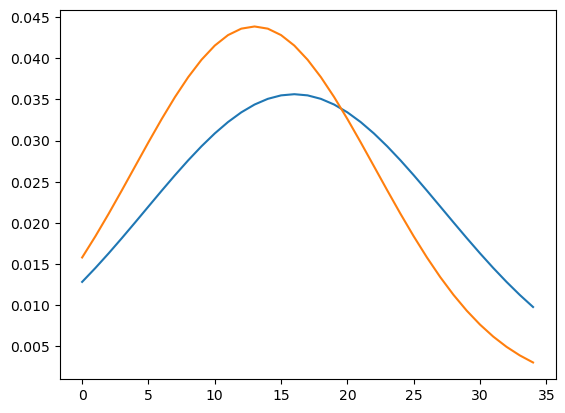

In [8]:
pdf_wide = scipy.stats.norm.pdf(np.arange(0,35,1),Lifetime_T,0.7*Lifetime_T) # pdf of the normal distribution with mean lifetime and wide standard deviation 0.7*lifetime
print(pdf_wide.shape)
print(pdf_wide)
plt.plot(pdf_wide.transpose()) # transpose to have time dimension on x axis

#### Task 2.2: Repeat the calculation of the lifetime for a narrower distribution, e.g., standard deviation = 0.1 * average lifetime!

(2, 35)
[[4.80912414e-23 2.04919534e-20 5.90818993e-18 1.15260170e-15
  1.52145033e-13 1.35890790e-11 8.21251136e-10 3.35827041e-08
  9.29199697e-07 1.73962714e-05 2.20372301e-04 1.88891127e-03
  1.09551878e-02 4.29914224e-02 1.14155678e-01 2.05100605e-01
  2.49338925e-01 2.05100605e-01 1.14155678e-01 4.29914224e-02
  1.09551878e-02 1.88891127e-03 2.20372301e-04 1.73962714e-05
  9.29199697e-07 3.35827041e-08 8.21251136e-10 1.35890790e-11
  1.52145033e-13 1.15260170e-15 5.90818993e-18 2.04919534e-20
  4.80912414e-23 7.63664030e-26 8.20526100e-29]
 [5.91892202e-23 9.64894677e-20 8.70438755e-17 4.34527778e-14
  1.20037761e-11 1.83501342e-09 1.55232131e-07 7.26683021e-06
  1.88247588e-04 2.69857720e-03 2.14072701e-02 9.39742237e-02
  2.28284919e-01 3.06878677e-01 2.28284919e-01 9.39742237e-02
  2.14072701e-02 2.69857720e-03 1.88247588e-04 7.26683021e-06
  1.55232131e-07 1.83501342e-09 1.20037761e-11 4.34527778e-14
  8.70438755e-17 9.64894677e-20 5.91892202e-23 2.00921468e-26
  3.77425365e-

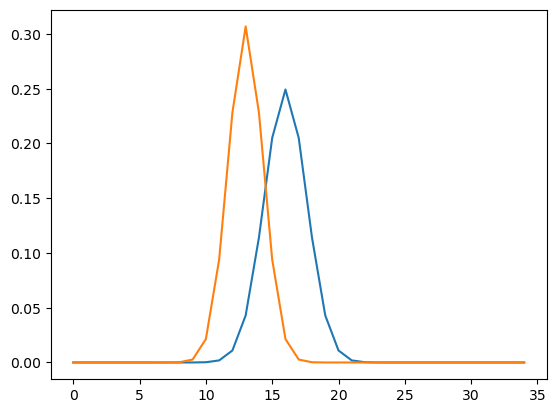

In [9]:
pdf_narrow = scipy.stats.norm.pdf(np.arange(0,35,1),Lifetime_T,0.1*Lifetime_T) # pdf of the normal distribution with mean lifetime and standard deviation 0.1*lifetime
print(pdf_narrow.shape)
print(pdf_narrow)
plt.plot(pdf_narrow.transpose()) # transpose to have time dimension on x axis

Note that the wider the lifetime distribution curve, the lower the values for the individual years, as the probability of discard is smoothed out across more years than with a more narrow distribution, and vice versa.

### Task 3: For the historic data: Estimate the outflow of old vehicles from the stock, and the stock (fleet size) itself, broken down by age-cohorts! Inspect and interpret the results!

We apply the **inflow-driven dynamic stock model** to tackle this question.

First, we define the result arrays for stock _S_ and outflow _O_ in their highest resolution, as matrices with the three dimensions time _t_, age-cohort _c_, and technology _T_.

We need the breakdown of all variables into age-cohorts because technology parameters, such as specific energy consumption and material composition, depend on the age-cohort of the vehicle.

In [10]:
# Define result arrays with maximum detail, tracing the different age-cohort separately:
S_tcT  = np.zeros((35,35,2)) # 3D stock table        for time t, age-cohort c, and drive technology T.
DS_tcT = np.zeros((35,35,2)) # 3D stock change table for time t, age-cohort c, and drive technology T.
O_tcT  = np.zeros((35,35,2)) # 3D outflow matrix     for time t, age-cohort c, and drive technology T.

Then, an implementation of the inflow-driven model is presented and commented below.
This implementation follows the three steps given in the lecture slides:
1. compute outflow from pdf * inflow
2. compute stock change from balancing equation
3. compute stock as cumulative summ of stock change

In [11]:
# Define result arrays with maximum detail, tracing the different age-cohort separately:
S_tcT  = np.zeros((35,35,2)) # 3D stock table        for time t, age-cohort c, and drive technology T.
DS_tcT = np.zeros((35,35,2)) # 3D stock change table for time t, age-cohort c, and drive technology T.
O_tcT  = np.zeros((35,35,2)) # 3D outflow matrix     for time t, age-cohort c, and drive technology T.

# The pdf indicates the probability of outflow of a given age-cohort.
# We can compute the stock change table and the outflow with a double for loop, the first one for the historic years 
# and the inner one for the different years until each year, the different age-cohorts:

# Define ancillary data container: The vehicles from different age-cohorts leaving in a given year:
veleave_t_c = np.zeros((35)) # length: number of age-cohorts

# Populate the outflow table from inflow
# Populate the stock change table from the balancing equation
for drivetech in range(0,2): # for all drive technologies
    for year in range(0,35): # for all historic years
        veleave_t_c = np.zeros((35)) # empty cohort-specific outflow container for this year
        for age_cohort in range(0,year+1): # for all inflow years till year (need to add 1 since Python stops counting 1 place before the right boundary)
            # Calculate leaving vehicles in given year, for the different age-cohorts:
            veleave_t_c[age_cohort] = I_cT[age_cohort,drivetech] * pdf[drivetech,year-age_cohort] 
        # Add the leaving vehicles to outflow matrix:
        O_tcT[year,:,drivetech]    += veleave_t_c # add leaving vehicles in place  
        # Compute the stock change of the given year, using the balancing equation
        DS_tcT[year,year,drivetech] = I_cT[year,drivetech]    # first, add the inflow for the given year = age-cohort 
        DS_tcT[year,:,drivetech]   -= O_tcT[year,:,drivetech] # substract outflow in place

# Calculate the stock as cumulative sum of the stock change
S_tcT = np.cumsum(DS_tcT, axis = 0)

# This completes the inflow-driven model.

Next, we inspect the main result arrays for stock and outflow, covering both gasoline and electric vehicles.

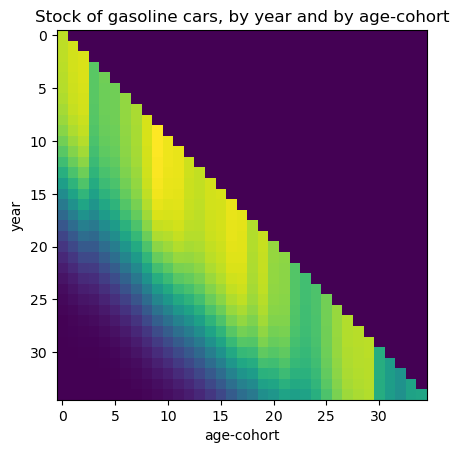

In [12]:
plt.imshow(S_tcT[:,:,0],interpolation='nearest') # create a simple heatmap: larger value --> brighter color.
plt.xlabel('age-cohort')    # add x axis label 
plt.ylabel('year')          # add y axis label
plt.title('Stock of gasoline cars, by year and by age-cohort') # add title
plt.show(); # show plot with all features from above

#### Task 3.1: Create a corresponding visualisation for the BEV stock!

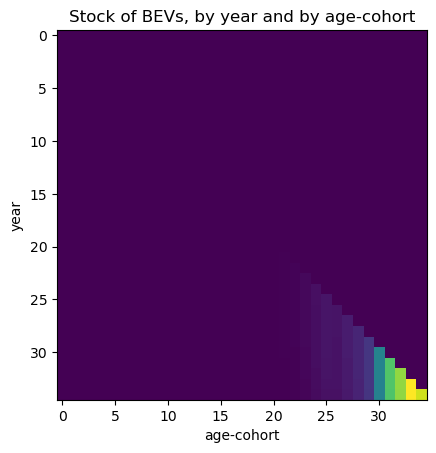

In [13]:
plt.imshow(S_tcT[:,:,1],interpolation='nearest') # create a simple heatmap: larger value --> brighter color.
plt.xlabel('age-cohort')    # add x axis label 
plt.ylabel('year')          # add y axis label
plt.title('Stock of BEVs, by year and by age-cohort') # add title
plt.show(); # show plot with all features from above

Let's look at the outflow now:

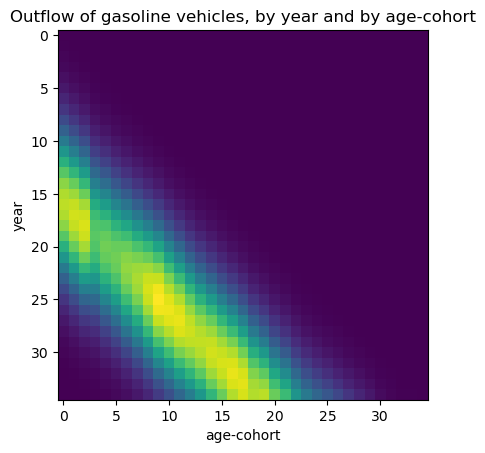

In [14]:
plt.imshow(O_tcT[:,:,0],interpolation='nearest') # create a simple heatmap: larger value --> brighter color.
plt.xlabel('age-cohort')    # add x axis label 
plt.ylabel('year')          # add y axis label
plt.title('Outflow of gasoline vehicles, by year and by age-cohort') # add title
plt.show(); # show plot with all features from above

#### Task 3.2: Create a corresponding visualisation for the BEV outflow!

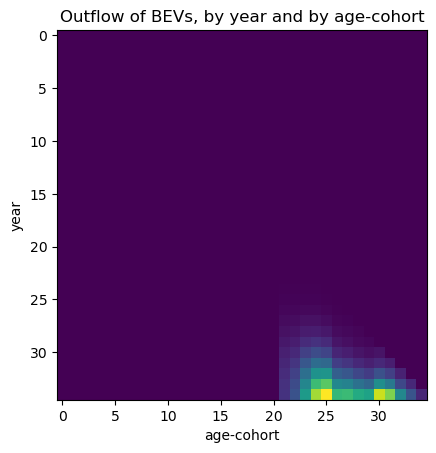

In [15]:
plt.imshow(O_tcT[:,:,1],interpolation='nearest') # create a simple heatmap: larger value --> brighter color.
plt.xlabel('age-cohort')    # add x axis label 
plt.ylabel('year')          # add y axis label
plt.title('Outflow of BEVs, by year and by age-cohort') # add title
plt.show(); # show plot with all features from above

With the information above, the following questions can now be answered:

**What is the meaning of the data shown above?** The stock table shows the size of the fleet of passenger vehicles for the EUR20 countries for each historic year from 1990 to 2024, given by the row index. For each year, the fleet consists of vehicles from different age-cohorts (year of manufacturing). For each year (row), the fleet can therefore be broken down into different age-cohorts (column index), showing the manufacturing year (from 1990 to 2024). The new cars of each year are on the diagonal, where year = age-cohort. 

**What is the meaning of the row index, and what is the meaning of the column index?** 
The row indicates the historic year, and the column the year of manufacturing (age-cohort). 

**Exactly how large was the car fleet in 2022?** to answer this question, we take the corresponding row of the table and sum it up. In Python, this is done as follows:

In [16]:
# First, select the row for 2022, which is the 32nd row, index 32, since in Python, we start counting at 0 (for 1990).
# Then, selet all columns (all age-cohorts) and drive technologies, indicated by ':'.
# Lastly, sum up over this table row by the .sum() command:
Stock_2022 = S_tcT[32,:,:].sum()
Stock_2022 # print the total stock in 2022, unit: vehicles

np.float64(160751665.99211222)

The total fleet size in the EUR20 countries in 2022 was about 161 million passenger vehicles.

Below, we plot the time series of the **total fleet size**:

Text(0.5, 0, 'Year')

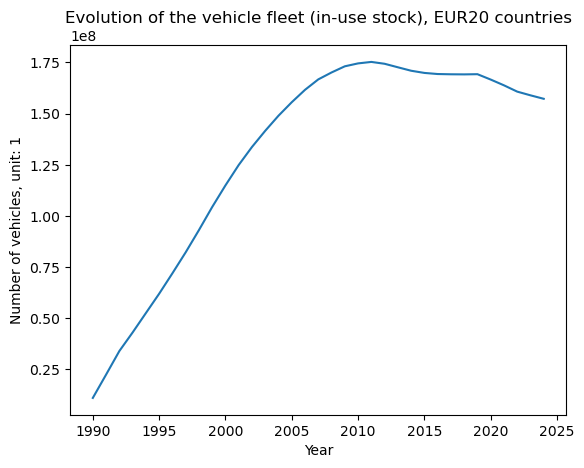

In [17]:
plt.plot(np.arange(1990,2025,1), np.einsum('tcT->t',S_tcT))
plt.title('Evolution of the vehicle fleet (in-use stock), EUR20 countries')
plt.ylabel('Number of vehicles, unit: 1')
plt.xlabel('Year')

**How many cars in 2022 were 10 years old or younger?**

In [18]:
# In 2022, the oldest age-cohort (1990) was 32 years old, so we need to slice all age-cohorts from 2012 (index 22) onwards:
Stock_2022_That_is_younger_than_10_years = S_tcT[32,22::,:].sum()
Stock_2022_That_is_younger_than_10_years

np.float64(101514654.62586364)

In 2022, there were about 102 million vehicles in the EUR20 countries that were 10 years old or younger.

**What is the meaning of a given column (age-cohort) in this table?**
A given table row traces a given age-cohort over time. The following plot illustrates this behaviour of the age-cohort of 1995:

In [19]:
np.arange(1990,2025,1)

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024])

In [20]:
S_tcT[:,5,0]

array([      0.        ,       0.        ,       0.        ,
             0.        ,       0.        , 9601916.83450287,
       9595869.16835811, 9584521.49520698, 9564133.41932838,
       9529058.54873971, 9471280.04026333, 9380144.66443497,
       9242500.41741951, 9043442.45564123, 8767796.60804836,
       8402308.0636507 , 7938277.59549496, 7374160.01027588,
       6717496.03373229, 5985570.05941487, 5204407.28385633,
       4406106.90883912, 3624944.13328058, 2893018.15896316,
       2236354.18241957, 1672236.59720049, 1208206.12904476,
        842717.58464709,  567071.73705422,  368013.77527594,
        230369.52826048,  139234.15243212,   81455.64395574,
         46380.77336707,   25992.69748847])

#### Task 3.3: Create a visualisation for the 1995 age-cohort in the EUR20 passenger vehicle fleet!

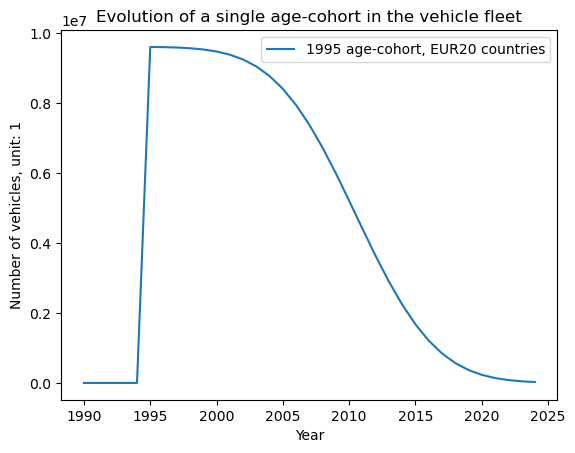

In [21]:
plt.plot(np.arange(1990,2025,1),S_tcT[:,5,0])
plt.title('Evolution of a single age-cohort in the vehicle fleet')
plt.ylabel('Number of vehicles, unit: 1')
plt.xlabel('Year')
plt.legend(['1995 age-cohort, EUR20 countries'])

#### Task 3.4: Create a visualisation of the end-of-life vehicles (outflow) since 1990 and starting with the 1990 age-cohort from the EUR20 passenger vehicle fleet! How many cars from the inflow since 1990 have already left the fleet?

To calculate the total outflow (all age-cohors and drive technologies in a given year), calculate a suitable aggregation of _O_tcT_ using the np.einsum function.

In [22]:
# We'll address the second question first, simply by adding up the total outflow:
Total_Outflow = O_tcT.sum()
Total_Outflow

np.float64(207745347.1833689)

Out of the 365 million vehicles that were registered since 1990, 208 million have already left the stock again, that is 208 million passenger vehicles over the last 35 years that were either exported to other world regions or send to the waste management industries for shredding.

We contine with plotting the outflow:

Text(0.5, 0, 'Year')

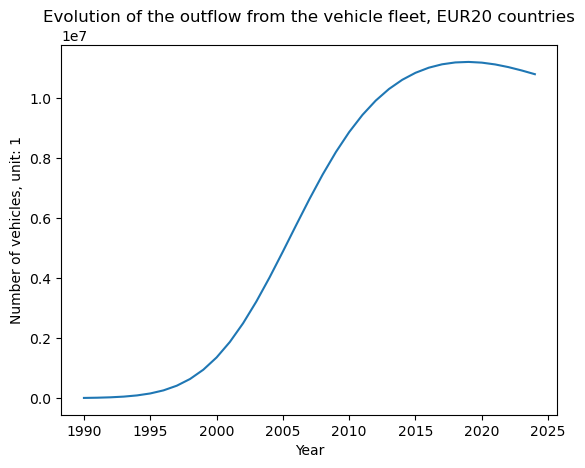

In [23]:
plt.plot(np.arange(1990,2025,1),np.einsum('tcT->t',O_tcT))
plt.title('Evolution of the outflow from the vehicle fleet, EUR20 countries')
plt.ylabel('Number of vehicles, unit: 1')
plt.xlabel('Year')

The outflow has risen steadily and recently stabilized at about 11 million vehicles/yr, stabilizin the fleet size at 155...175 million units. 

Note that pre-1990 age-cohorts are not covered here, which is why this outflow only covers part of the total outflow (the post 1989 age-cohorts).

Since about 2020, the pre 1990 age-cohorts don't play a role anymore, and the 1900 truncation is not relevant anymore, the stock by age-cohort is accurate enough to use it for further modelling.

### Task 4: Show that inflow, stock, and outflow are balanced for vehicles in each year!

In [24]:
# First, sum up over all age-cohorts, using the einsum function:
S_tT  = np.einsum('tcT->tT',S_tcT)
O_tT  = np.einsum('tcT->tT',O_tcT)
DS_tT = np.diff(S_tT,axis = 0, prepend=0) # re-calculate the stock change from the stock, starting with 0 in the first year (prepdent = 0)

Balance = I_cT-O_tT-DS_tT

In [25]:
np.abs(Balance).sum() # add up all absolute values in this balance, should be 0 or at least close to it.

np.float64(5.427828000392765e-07)

The overall added imbalance is less than a millionth of a single car, from a practical perspective, the dynamic stock model is hence balanced.

### Task 5: Store the stock and outflow tables for further use!

We'll need the 1900-2025 stock table to initialize the stock-driven model in the subsequent workbooks.

In [26]:
pd_xlsx_writer = pd.ExcelWriter('Bath_dMFA_2026_Software_2_Results.xlsx')

In [27]:
export_df1= pd.DataFrame(data=S_tcT[:,:,0],   # entire t x c stock table for gasoline cars
            index  =np.arange(1990,2025,1),   # 1st column as index
            columns=np.arange(1990,2025,1))   # 1st row as the column names

export_df1.to_excel(pd_xlsx_writer, sheet_name="Stock_tc_gasoline", merge_cells=False)   

export_df2= pd.DataFrame(data=S_tcT[:,:,1],   # entire t x c stock table for BEVs
            index  =np.arange(1990,2025,1),   # 1st column as index
            columns=np.arange(1990,2025,1))   # 1st row as the column names

export_df2.to_excel(pd_xlsx_writer, sheet_name="Stock_tc_BEVs", merge_cells=False) 

export_df3= pd.DataFrame(data=O_tcT[:,:,0],   # entire t x c outflow table for gasoline cars
            index  =np.arange(1990,2025,1),   # 1st column as index
            columns=np.arange(1990,2025,1))   # 1st row as the column names

export_df3.to_excel(pd_xlsx_writer, sheet_name="Outflow_tc_gasoline", merge_cells=False)   

export_df4= pd.DataFrame(data=O_tcT[:,:,1],   # entire t x c outflow table for BEVs
            index  =np.arange(1990,2025,1),   # 1st column as index
            columns=np.arange(1990,2025,1))   # 1st row as the column names

export_df4.to_excel(pd_xlsx_writer, sheet_name="Outflow_tc_BEVs", merge_cells=False) 

In [28]:
pd_xlsx_writer.close()

This export concludes this exercise.